# EDA Trạm 1 — Acronym Disambiguation (Cross-Encoder)

Notebook này phân tích độ khó dữ liệu acronym và cấu trúc mẫu huấn luyện cho kiến trúc Cross-Encoder.

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

BASE_DIR = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
FIG_DIR = BASE_DIR / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DICT_PATH = BASE_DIR / "data" / "acrDrAid" / "dictionary.json"
TRAIN_PATH = BASE_DIR / "data" / "acrDrAid" / "train" / "data.json"

print("BASE_DIR:", BASE_DIR)
print("Dictionary:", DICT_PATH)
print("Train:", TRAIN_PATH)

BASE_DIR: C:\Users\User\Desktop\Chatbot-Y tế
Dictionary: C:\Users\User\Desktop\Chatbot-Y tế\data\acrDrAid\dictionary.json
Train: C:\Users\User\Desktop\Chatbot-Y tế\data\acrDrAid\train\data.json


## 1) Phân tích Từ điển Acronym (`dictionary.json`)

Mục tiêu: đo mức đa nghĩa của từ viết tắt và đặc trưng độ dài acronym/expansion để đánh giá độ khó bài toán WSD.

In [2]:
with open(DICT_PATH, "r", encoding="utf-8") as f:
    acronym_dict = json.load(f)

rows = []
for acro, expansions in acronym_dict.items():
    for exp in expansions:
        rows.append({"acronym": acro, "expansion": exp, "n_senses": len(expansions)})

df_dict = pd.DataFrame(rows)
df_multi = (
    df_dict[["acronym", "n_senses"]]
    .drop_duplicates()
    .sort_values("n_senses", ascending=False)
)

avg_acro_len = df_multi["acronym"].str.len().mean()
avg_exp_len_char = df_dict["expansion"].str.len().mean()
avg_exp_len_word = df_dict["expansion"].str.split().str.len().mean()

print(f"Số acronym: {df_multi.shape[0]}")
print(f"Tổng expansion entries: {df_dict.shape[0]}")
print(f"Độ dài acronym trung bình (ký tự): {avg_acro_len:.2f}")
print(f"Độ dài expansion trung bình (ký tự): {avg_exp_len_char:.2f}")
print(f"Độ dài expansion trung bình (từ): {avg_exp_len_word:.2f}")
df_multi.head(10)

Số acronym: 135
Tổng expansion entries: 424
Độ dài acronym trung bình (ký tự): 2.07
Độ dài expansion trung bình (ký tự): 8.40
Độ dài expansion trung bình (từ): 2.04


,acronym,n_senses
48,tt,17
40,bt,8
133,nt,8
170,tp,8
9,tn,7
22,tc,7
108,ht,7
239,đt,7
94,ct,7
371,kk,5


C:\Users\User\AppData\Local\Temp\ipykernel_15908\579749600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, x="n_senses", y="acronym", palette="viridis", ax=ax)


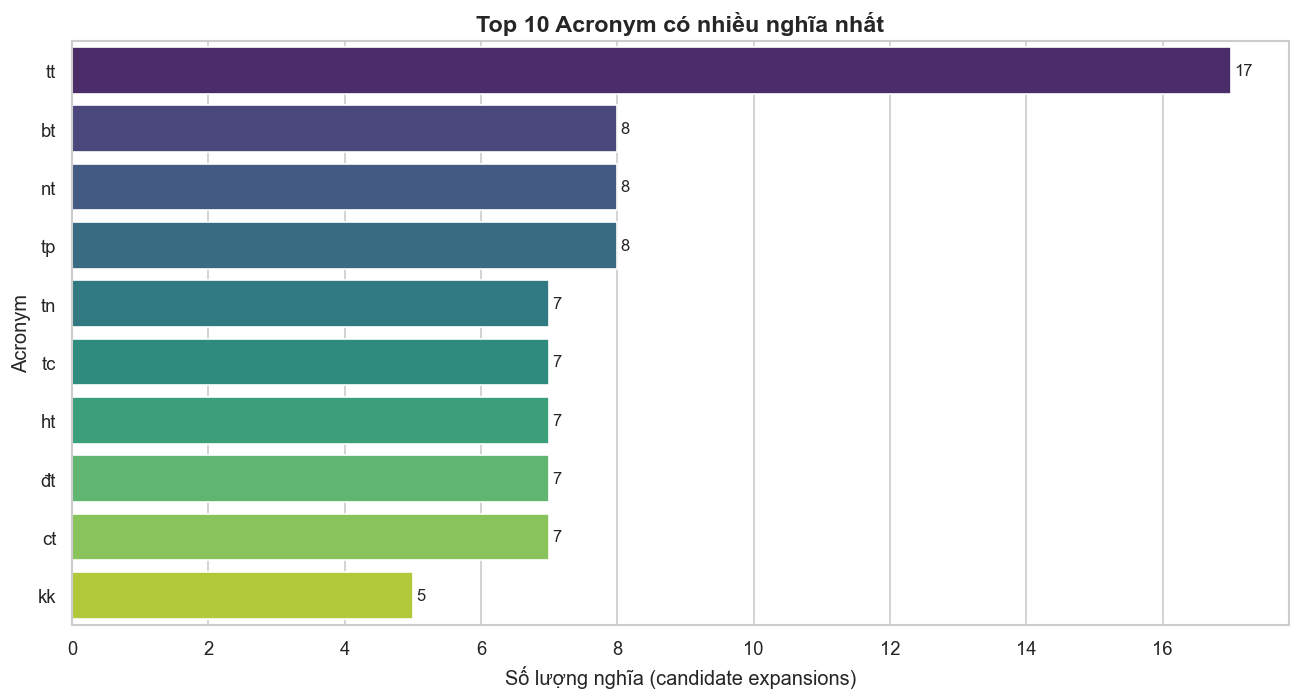

In [3]:
top10 = df_multi.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top10, x="n_senses", y="acronym", palette="viridis", ax=ax)
ax.set_title("Top 10 Acronym có nhiều nghĩa nhất", fontsize=14, fontweight="bold")
ax.set_xlabel("Số lượng nghĩa (candidate expansions)")
ax.set_ylabel("Acronym")

for p in ax.patches:
    val = int(p.get_width())
    ax.annotate(
        f"{val}",
        (p.get_width() + 0.05, p.get_y() + p.get_height() / 2),
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "tram1_top10_acronym_multisense.png", dpi=300, bbox_inches="tight")
plt.show()

> **💡 Insight rút ra:** Các acronym đa nghĩa nhất là những điểm nghẽn chính của bài toán WSD. Cross-Encoder cần phân biệt dựa trên ngữ cảnh thay vì chỉ nhìn bề mặt acronym.

C:\Users\User\AppData\Local\Temp\ipykernel_15908\3972461722.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=len_stats, x="value", y="metric", palette="Set2", ax=ax)


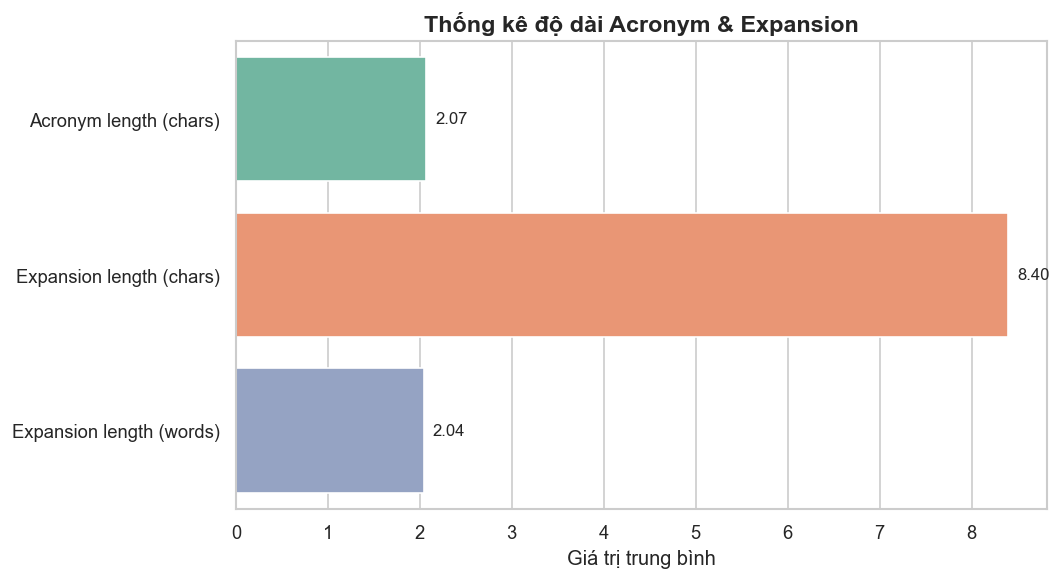

In [4]:
len_stats = pd.DataFrame(
    {
        "metric": [
            "Acronym length (chars)",
            "Expansion length (chars)",
            "Expansion length (words)",
        ],
        "value": [avg_acro_len, avg_exp_len_char, avg_exp_len_word],
    }
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=len_stats, x="value", y="metric", palette="Set2", ax=ax)
ax.set_title("Thống kê độ dài Acronym & Expansion", fontsize=14, fontweight="bold")
ax.set_xlabel("Giá trị trung bình")
ax.set_ylabel("")

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (p.get_width() + 0.1, p.get_y() + p.get_height() / 2),
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.savefig(FIG_DIR / "tram1_length_statistics.png", dpi=300, bbox_inches="tight")
plt.show()

> **💡 Insight rút ra:** Acronym thường rất ngắn nhưng expansion dài hơn nhiều, tạo độ lệch biểu diễn rõ rệt. Điều này giải thích vì sao mô hình cần cơ chế so khớp ngữ nghĩa sâu giữa context và candidate.

## 2) Phân tích Cấu trúc Cross-Encoder trên Train Data

Mục tiêu: định lượng tỷ lệ Positive/Negative sau Hard Negative Mining và phân bố độ dài input sau entity marking + nối candidate.

In [5]:
with open(TRAIN_PATH, "r", encoding="utf-8") as f:
    train_samples = json.load(f)

pos_count = 0
neg_count = 0
pair_lengths = []

for s in train_samples:
    text = s["text"]
    start = s["start_char_idx"]
    length = s["length_acronym"]
    acronym = text[start : start + length]
    correct = s["expansion"]

    if acronym not in acronym_dict:
        continue

    marked = text[:start] + " <e>" + acronym + "</e> " + text[start + length :]
    candidates = acronym_dict[acronym]

    for cand in candidates:
        label = 1 if cand == correct else 0
        pos_count += label
        neg_count += 1 - label

        # Ước lượng chiều dài input: context + [SEP] + candidate (word-level approximation)
        pair_len = len(marked.split()) + 1 + len(cand.split())
        pair_lengths.append(pair_len)

print(f"Train samples: {len(train_samples)}")
print(f"Total generated pairs: {pos_count + neg_count}")
print(f"Positive pairs: {pos_count}")
print(f"Negative pairs: {neg_count}")

Train samples: 4000
Total generated pairs: 12656
Positive pairs: 4000
Negative pairs: 8656


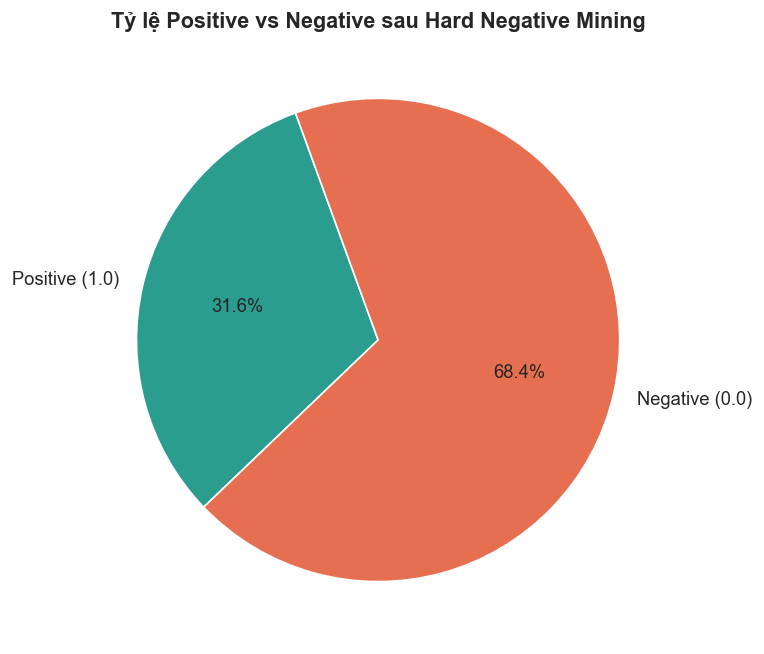

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
labels = ["Positive (1.0)", "Negative (0.0)"]
values = [pos_count, neg_count]
colors = ["#2a9d8f", "#e76f51"]

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct="%1.1f%%",
    startangle=110,
    colors=colors,
    textprops={"fontsize": 11},
)
ax.set_title("Tỷ lệ Positive vs Negative sau Hard Negative Mining", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR / "tram1_pos_neg_ratio_pie.png", dpi=300, bbox_inches="tight")
plt.show()

> **💡 Insight rút ra:** Tập huấn luyện pair-level luôn lệch về Negative do mỗi acronym có nhiều candidate sai hơn đúng. Đây là đặc tính tự nhiên của Hard Negative Mining và là lý do cần theo dõi loss/threshold cẩn thận khi huấn luyện.

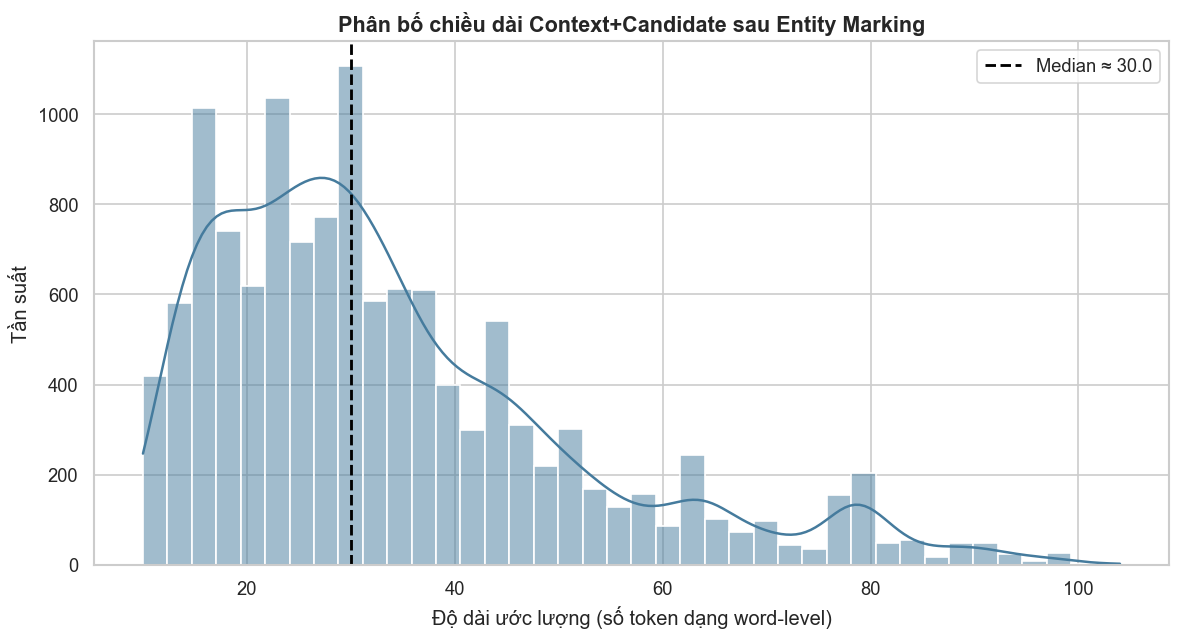

In [7]:
df_len = pd.DataFrame({"pair_token_len_approx": pair_lengths})

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.histplot(
    data=df_len,
    x="pair_token_len_approx",
    bins=40,
    kde=True,
    color="#457b9d",
    ax=ax,
)
ax.set_title("Phân bố chiều dài Context+Candidate sau Entity Marking", fontsize=13, fontweight="bold")
ax.set_xlabel("Độ dài ước lượng (số token dạng word-level)")
ax.set_ylabel("Tần suất")

median_len = float(np.median(pair_lengths))
ax.axvline(median_len, color="black", linestyle="--", linewidth=1.7, label=f"Median ≈ {median_len:.1f}")
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "tram1_pair_length_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

> **💡 Insight rút ra:** Đa số cặp input tập trung ở vùng độ dài trung bình và thấp hơn giới hạn tokenizer thường dùng (`max_length=128` hoặc `256`), nên nguy cơ cắt cụt thông tin trọng yếu không quá lớn trong thực tế.

C:\Users\User\AppData\Local\Temp\ipykernel_17352\3179759320.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Meanings_Count', y='Acronym', data=top_10, palette='magma')


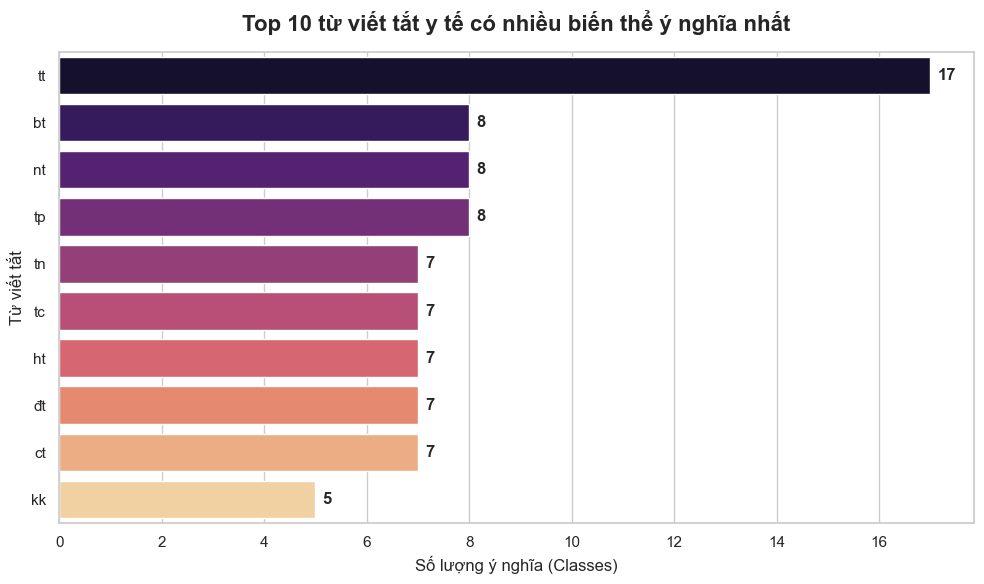

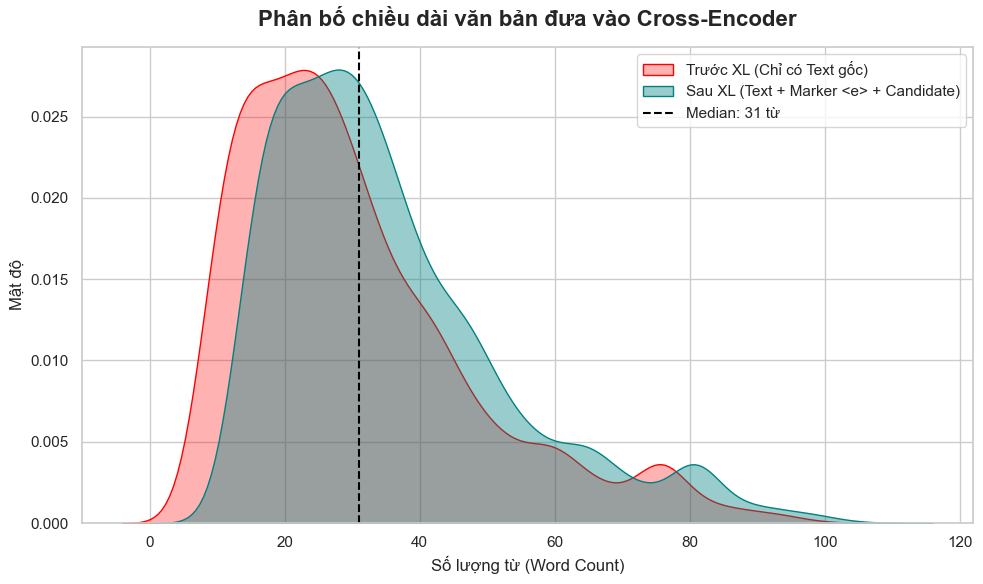

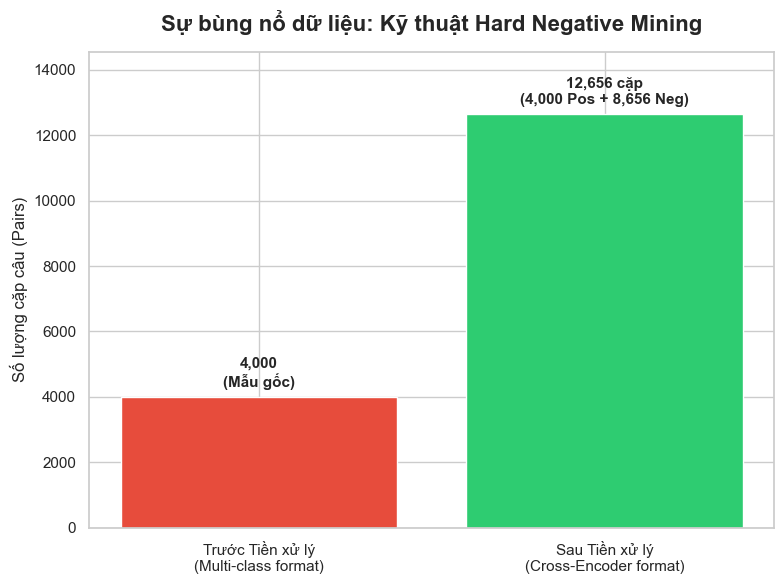

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Đọc Data
with open(r"C:\Users\User\Desktop\Chatbot-Y tế\data\acrDrAid\train\data.json", "r", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))
with open(r"C:\Users\User\Desktop\Chatbot-Y tế\data\acrDrAid\dictionary.json", "r", encoding="utf-8") as f:
    dictionary = json.load(f)

sns.set_theme(style="whitegrid")

# 1. BIỂU ĐỒ TỪ ĐIỂN (ĐỘ KHÓ)
meanings_count = {k: len(v) for k, v in dictionary.items()}
df_dict = pd.DataFrame(list(meanings_count.items()), columns=['Acronym', 'Meanings_Count'])
top_10 = df_dict.sort_values(by='Meanings_Count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Meanings_Count', y='Acronym', data=top_10, palette='magma')
plt.title('Top 10 từ viết tắt y tế có nhiều biến thể ý nghĩa nhất', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượng ý nghĩa (Classes)', fontsize=12)
plt.ylabel('Từ viết tắt', fontsize=12)
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\Chatbot-Y tế\reports\figures\acronym_top10_ambiguity.png', dpi=300)
plt.show()

# 2. BIỂU ĐỒ CHIỀU DÀI TEXT CROSS-ENCODER
df['raw_word_count'] = df['text'].apply(lambda x: len(x.split()))
df['processed_word_count'] = df.apply(lambda r: len(r['text'].split()) + len(str(r.get('expansion', '')).split()) + 3, axis=1)

plt.figure(figsize=(10, 6))
sns.kdeplot(df['raw_word_count'], label='Trước XL (Chỉ có Text gốc)', fill=True, color='red', alpha=0.3)
sns.kdeplot(df['processed_word_count'], label='Sau XL (Text + Marker <e> + Candidate)', fill=True, color='teal', alpha=0.4)
plt.axvline(df['processed_word_count'].median(), color='black', linestyle='--', label=f"Median: {df['processed_word_count'].median():.0f} từ")
plt.title('Phân bố chiều dài văn bản đưa vào Cross-Encoder', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượng từ (Word Count)')
plt.ylabel('Mật độ')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\Chatbot-Y tế\reports\figures\acronym_text_length.png', dpi=300)
plt.show()

# 3. BIỂU ĐỒ BÙNG NỔ DỮ LIỆU (HARD NEGATIVE MINING)
df['k_meanings'] = df.apply(lambda r: meanings_count.get(r['text'][r['start_char_idx']:r['start_char_idx']+r['length_acronym']].lower(), 1), axis=1)

total_raw = len(df)
total_pos = len(df)
total_neg = (df['k_meanings'] - 1).sum()
total_proc = total_pos + total_neg

plt.figure(figsize=(8, 6))
plt.bar(['Trước Tiền xử lý\n(Multi-class format)', 'Sau Tiền xử lý\n(Cross-Encoder format)'], 
        [total_raw, total_proc], color=['#e74c3c', '#2ecc71'])
plt.title('Sự bùng nổ dữ liệu: Kỹ thuật Hard Negative Mining', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Số lượng cặp câu (Pairs)')

plt.text(0, total_raw + 200, f"{total_raw:,}\n(Mẫu gốc)", ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.text(1, total_proc + 200, f"{total_proc:,} cặp\n({total_pos:,} Pos + {total_neg:,} Neg)", ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.ylim(0, total_proc * 1.15)
plt.tight_layout()
plt.savefig(r'C:\Users\User\Desktop\Chatbot-Y tế\reports\figures\acronym_data_explosion.png', dpi=300)
plt.show()